# Image Data Augmentation

**Data augmentation** is a technique to artificially expand your training dataset by creating modified versions of existing images. It's one of the most effective ways to improve model generalization and reduce overfitting.

In this notebook, we'll explore:
- Why data augmentation works
- Core augmentation techniques (rotation, flip, crop, color jitter)
- How to combine augmentations effectively
- The impact on model performance

## 1. Why Data Augmentation?

**The Problem**: Deep learning models are data-hungry, but collecting labeled data is expensive and time-consuming.

**The Solution**: Data augmentation creates variations of existing images that preserve the label but change the appearance. A photo of a cat is still a cat whether it's rotated, flipped, or slightly color-shifted.

**The Benefit**: Models learn to recognize objects under different conditions, making them more robust and generalizable.

## 2. Setup

Let's import the libraries we'll need. We'll use PyTorch's `torchvision.transforms` for augmentation operations.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from aiml_notebooks import set_seed, get_device

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility.

In [2]:
set_seed(42)

Configure device for computation.

In [3]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 3. Load Sample Data

We'll use CIFAR-10, a dataset of 32×32 color images in 10 classes. Let's load a few images to experiment with.

In [4]:
# Load CIFAR-10 without any augmentation first
dataset = CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())

# Get class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Dataset size: {len(dataset)} images")
print(f"Classes: {class_names}")

Dataset size: 50000 images
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Let's create a helper function to display images side by side for comparison.

In [5]:
def show_images(images, titles=None, figsize=(15, 5)):
    """Display multiple images in a row."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    
    for i, (img, ax) in enumerate(zip(images, axes)):
        # Convert tensor to numpy if needed
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).cpu().numpy()
        
        # Clip values to [0, 1] range
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.axis('off')
        if titles:
            ax.set_title(titles[i])
    
    plt.tight_layout()
    plt.show()

Select a sample image to work with throughout this notebook.

Image shape: torch.Size([3, 32, 32])
Label: frog


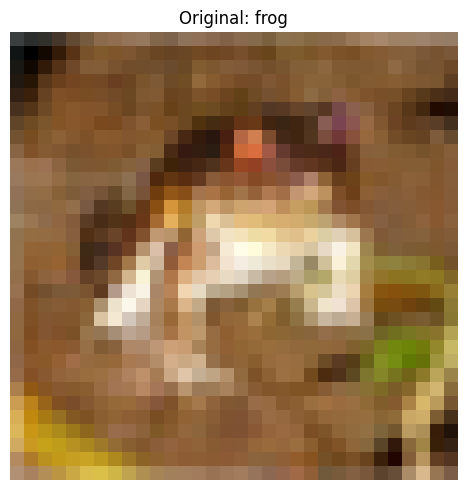

In [6]:
# Get a sample image - let's use an airplane
sample_idx = 0
sample_img, sample_label = dataset[sample_idx]

print(f"Image shape: {sample_img.shape}")
print(f"Label: {class_names[sample_label]}")
show_images([sample_img], titles=[f"Original: {class_names[sample_label]}"])

## 4. Rotation

**Rotation** rotates an image by a specified angle. This is useful because objects can appear at any orientation in real-world scenarios.

**Key insight**: A rotated airplane is still an airplane. Training on rotated versions helps the model recognize objects regardless of orientation.

Let's rotate our sample image by different angles.

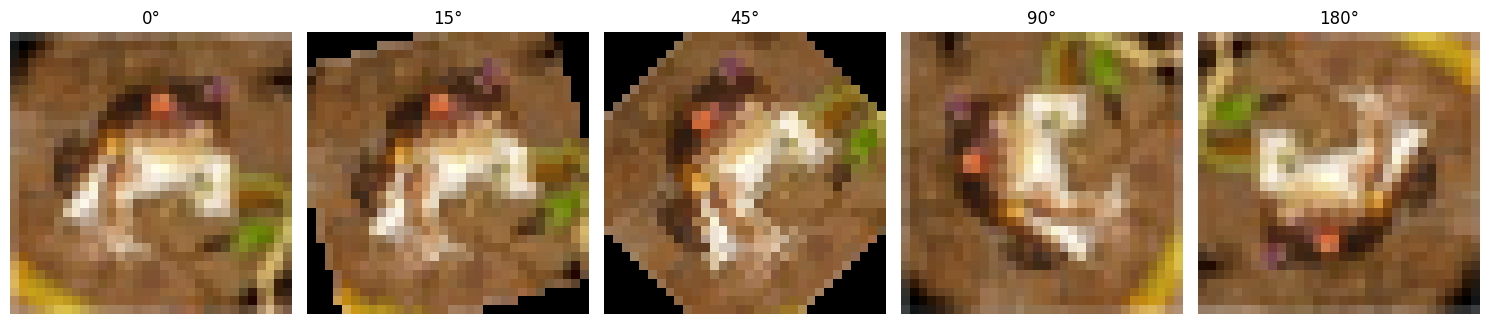

In [7]:
# Define rotation transform
angles = [0, 15, 45, 90, 180]
rotated_images = []

for angle in angles:
    rotated = TF.rotate(sample_img, angle)
    rotated_images.append(rotated)

show_images(rotated_images, titles=[f"{angle}°" for angle in angles])

Notice how the image remains recognizable across different rotations. However, extreme rotations (like 90° or 180°) might not always be appropriate depending on your task.

**Best practice**: Use small random rotations (±15°) for most tasks. Only use large rotations if objects can truly appear in any orientation.

Let's create a transform with random rotation within a range.

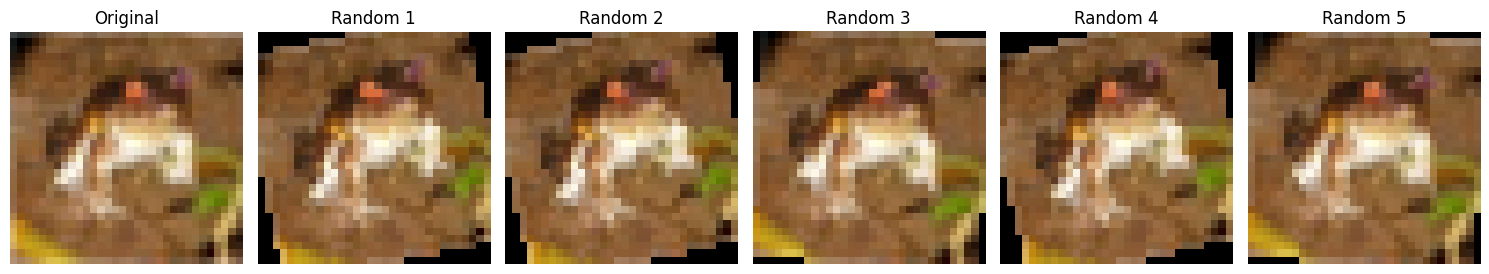

In [8]:
# RandomRotation applies random rotation within a range
random_rotation = transforms.RandomRotation(degrees=15)

# Apply multiple times to see variation
random_rotated = [random_rotation(sample_img) for _ in range(5)]
show_images([sample_img] + random_rotated, 
            titles=["Original"] + [f"Random {i+1}" for i in range(5)])

Each application produces a different random rotation within ±15°. This randomness is applied during training, creating diverse augmented samples.

## 5. Horizontal and Vertical Flip

**Flipping** mirrors an image horizontally or vertically. This is one of the simplest yet most effective augmentations.

**Horizontal flip**: Mirrors left ↔ right (useful for most objects)
**Vertical flip**: Mirrors top ↔ bottom (less common, not always semantically valid)

Let's see both flip operations.

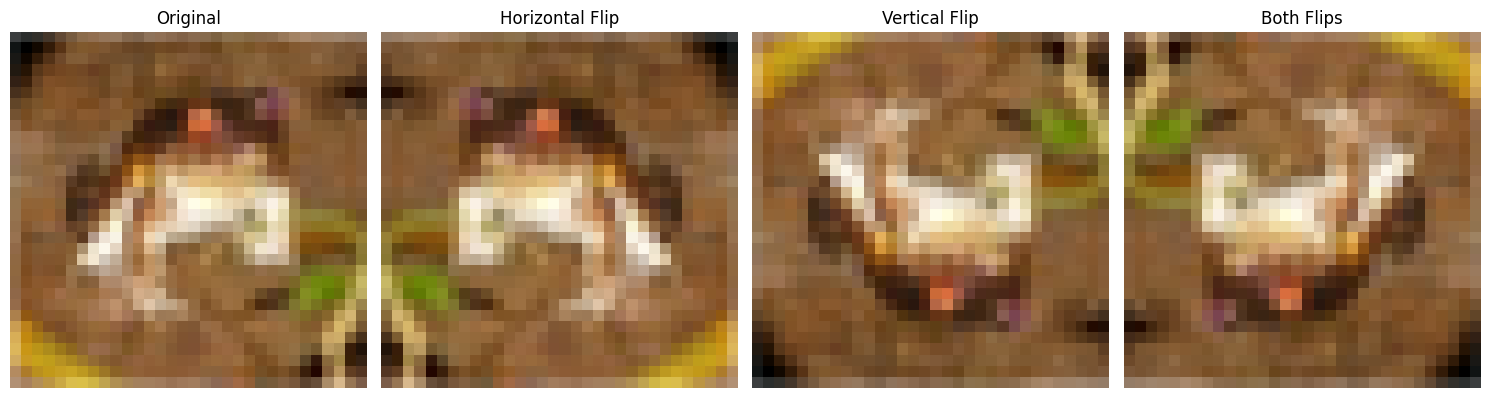

In [9]:
# Apply flips
h_flipped = TF.hflip(sample_img)
v_flipped = TF.vflip(sample_img)
both_flipped = TF.vflip(TF.hflip(sample_img))

show_images([sample_img, h_flipped, v_flipped, both_flipped],
            titles=["Original", "Horizontal Flip", "Vertical Flip", "Both Flips"])

**Important consideration**: Not all flips make sense for every task.

- **Horizontal flip**: Generally safe (a cat facing left is still a cat)
- **Vertical flip**: Often not semantically valid (an upside-down car is unusual)

**Best practice**: Use horizontal flip liberally, but use vertical flip only when objects can appear in any orientation (e.g., satellite imagery, medical imaging).

Random flips are applied with a probability (typically 50%).

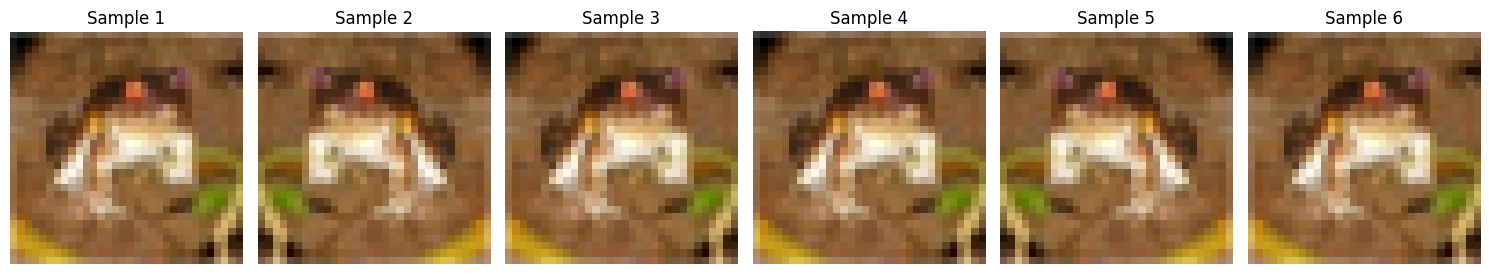

In [10]:
# RandomHorizontalFlip has 50% chance of flipping
random_h_flip = transforms.RandomHorizontalFlip(p=0.5)

# Apply multiple times - notice some are flipped, some aren't
random_flipped = [random_h_flip(sample_img) for _ in range(6)]
show_images(random_flipped, titles=[f"Sample {i+1}" for i in range(6)])

About half of the samples are flipped. This 50% probability ensures the model sees both orientations during training.

## 6. Random Crop

**Random crop** extracts a random portion of the image. This is powerful because:
1. It forces the model to recognize objects even when partially visible
2. It provides translation invariance (objects can appear anywhere in the frame)
3. It acts as a form of zooming in/out

Let's try random cropping at different scales.

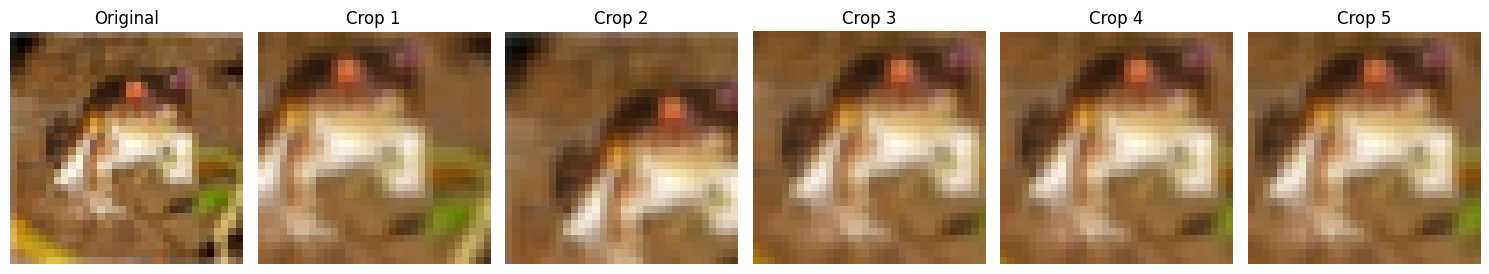

In [11]:
# RandomCrop extracts a random patch of specified size
# Our image is 32x32, so let's crop to 24x24 and resize back
crop_transform = transforms.Compose([
    transforms.RandomCrop(size=24),
    transforms.Resize(32)
])

# Apply multiple times to see different crops
cropped = [crop_transform(sample_img) for _ in range(5)]
show_images([sample_img] + cropped,
            titles=["Original"] + [f"Crop {i+1}" for i in range(5)])

Each crop captures a different part of the image. Notice how some crops might focus on different regions of the airplane.

**RandomResizedCrop** is even more powerful - it crops AND scales randomly.

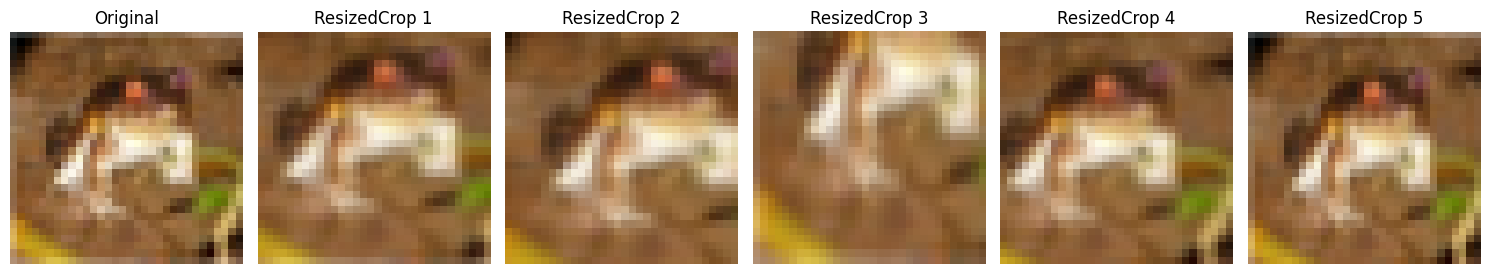

In [12]:
# RandomResizedCrop: crop random area and aspect ratio, then resize
# scale: range of area to crop (e.g., 0.5 to 1.0 means crop 50-100% of image)
resized_crop = transforms.RandomResizedCrop(size=32, scale=(0.5, 1.0), ratio=(0.75, 1.33))

resized_cropped = [resized_crop(sample_img) for _ in range(5)]
show_images([sample_img] + resized_cropped,
            titles=["Original"] + [f"ResizedCrop {i+1}" for i in range(5)])

This creates more varied augmentations by combining cropping, scaling, and aspect ratio changes. It's particularly effective for object recognition tasks.

## 7. Color Jitter

**Color jitter** randomly changes brightness, contrast, saturation, and hue. This makes models robust to:
- Different lighting conditions
- Camera settings
- Time of day
- Weather conditions

**Key insight**: The semantic content (a cat) doesn't change if the image is brighter, darker, or has different colors.

Let's explore each color jitter component individually.

### 7.1 Brightness

**Brightness** changes how light or dark the image appears.

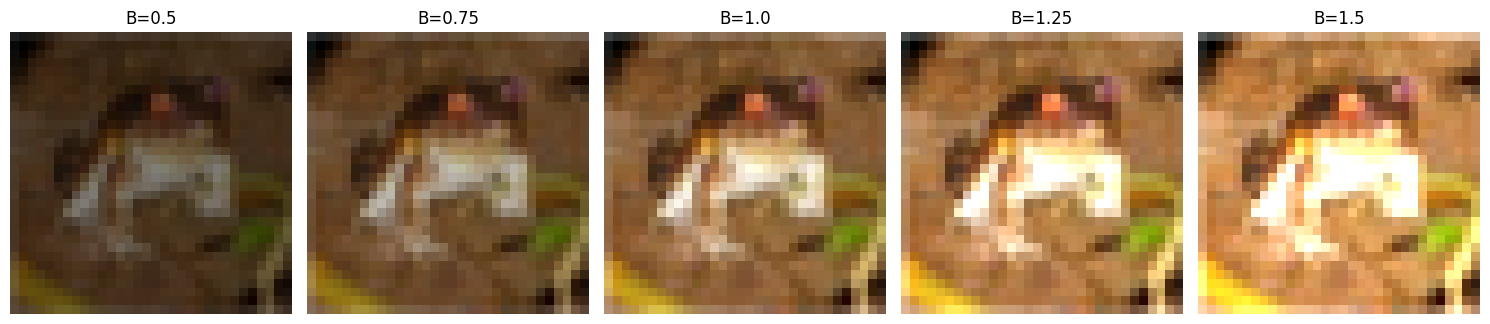

In [13]:
# Brightness: 0 = black, 1 = original, 2 = twice as bright
brightness_levels = [0.5, 0.75, 1.0, 1.25, 1.5]
bright_images = [TF.adjust_brightness(sample_img, brightness_factor=b) for b in brightness_levels]

show_images(bright_images, titles=[f"B={b}" for b in brightness_levels])

### 7.2 Contrast

**Contrast** changes the difference between light and dark areas.

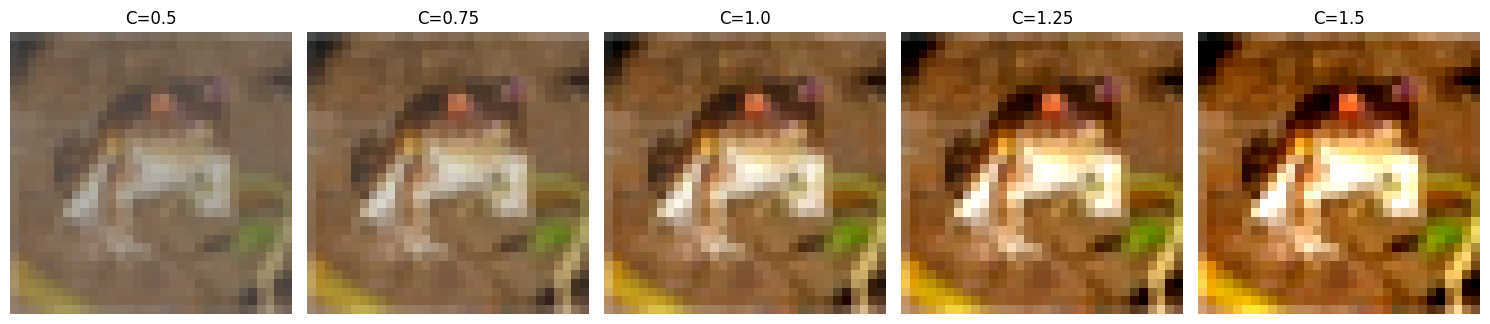

In [14]:
# Contrast: 0 = gray, 1 = original, >1 = higher contrast
contrast_levels = [0.5, 0.75, 1.0, 1.25, 1.5]
contrast_images = [TF.adjust_contrast(sample_img, contrast_factor=c) for c in contrast_levels]

show_images(contrast_images, titles=[f"C={c}" for c in contrast_levels])

### 7.3 Saturation

**Saturation** changes color intensity (vividness).

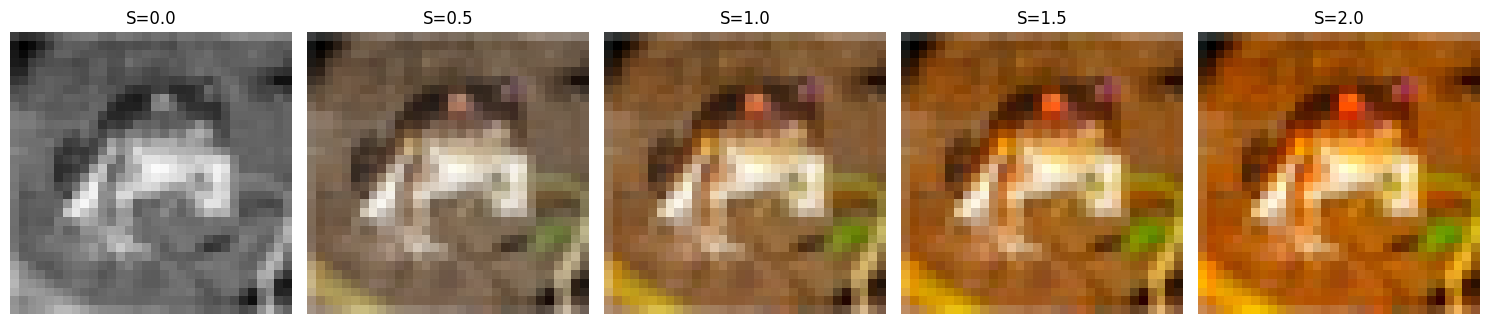

In [15]:
# Saturation: 0 = grayscale, 1 = original, >1 = more vivid
saturation_levels = [0.0, 0.5, 1.0, 1.5, 2.0]
saturation_images = [TF.adjust_saturation(sample_img, saturation_factor=s) for s in saturation_levels]

show_images(saturation_images, titles=[f"S={s}" for s in saturation_levels])

### 7.4 Hue

**Hue** shifts colors along the color wheel (red → green → blue → red).

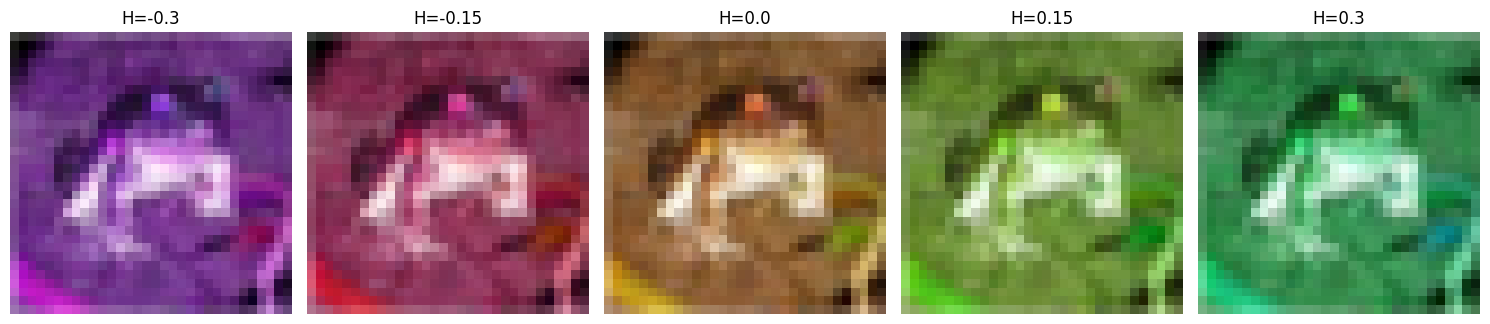

In [16]:
# Hue: range [-0.5, 0.5] shifts colors around the color wheel
hue_levels = [-0.3, -0.15, 0.0, 0.15, 0.3]
hue_images = [TF.adjust_hue(sample_img, hue_factor=h) for h in hue_levels]

show_images(hue_images, titles=[f"H={h}" for h in hue_levels])

### 7.5 Combined Color Jitter

In practice, we combine all four adjustments randomly.

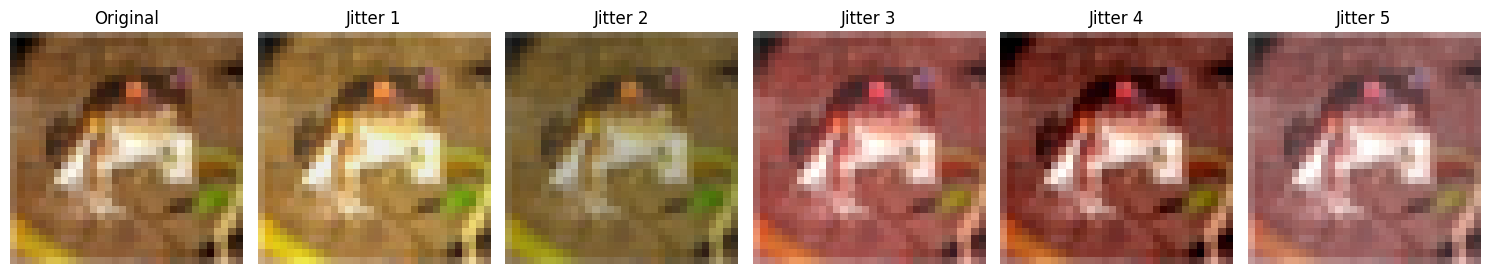

In [17]:
# ColorJitter randomly applies all four adjustments
# Parameters specify the range: 0.2 means ±20% variation
color_jitter = transforms.ColorJitter(
    brightness=0.3,  # ±30% brightness
    contrast=0.3,    # ±30% contrast
    saturation=0.3,  # ±30% saturation
    hue=0.1          # ±10% hue shift
)

jittered_images = [color_jitter(sample_img) for _ in range(5)]
show_images([sample_img] + jittered_images,
            titles=["Original"] + [f"Jitter {i+1}" for i in range(5)])

Each augmented image looks different in terms of color and lighting, but the airplane remains recognizable. This is exactly what we want!

## 8. Putting It All Together

The real power comes from **combining multiple augmentations**. Each augmentation addresses a different type of variation, and together they make models much more robust.

Let's create a comprehensive augmentation pipeline.

In [18]:
# Standard augmentation pipeline for image classification
augmentation_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),              # 50% chance of horizontal flip
    transforms.RandomRotation(degrees=15),               # Rotate ±15°
    transforms.RandomResizedCrop(size=32, scale=(0.8, 1.0)),  # Crop 80-100% of image
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
])

print("Augmentation pipeline:")
print(augmentation_pipeline)

Augmentation pipeline:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    RandomResizedCrop(size=(32, 32), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
)


Apply the full pipeline multiple times to see the combined effect.

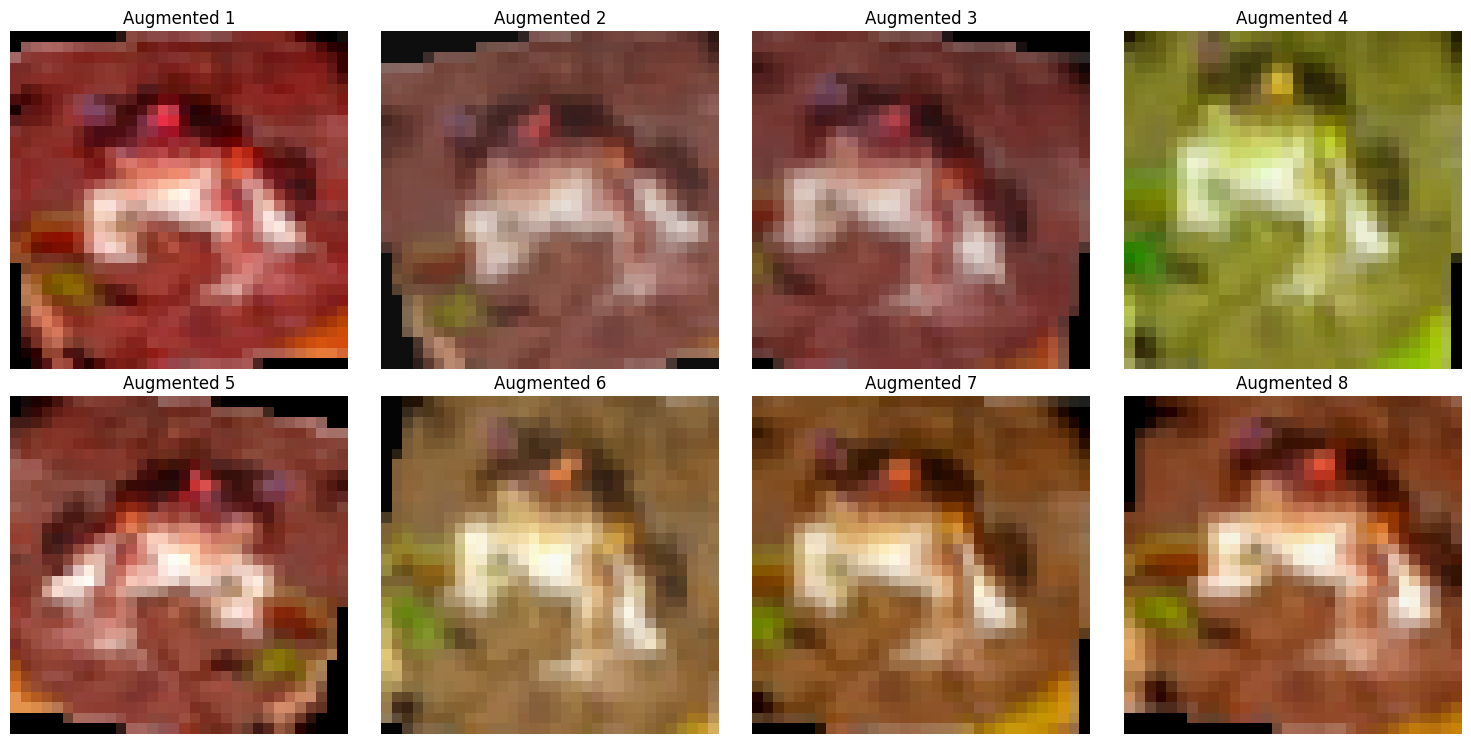

In [19]:
augmented_images = [augmentation_pipeline(sample_img) for _ in range(8)]

# Show in 2 rows
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
axes = axes.flatten()

for i, (img, ax) in enumerate(zip(augmented_images, axes)):
    img_np = img.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)
    ax.imshow(img_np)
    ax.axis('off')
    ax.set_title(f"Augmented {i+1}")

plt.tight_layout()
plt.show()

Notice how each augmented image is unique, yet all clearly show an airplane. This is the beauty of data augmentation!

Let's compare: no augmentation vs. full augmentation on multiple samples.

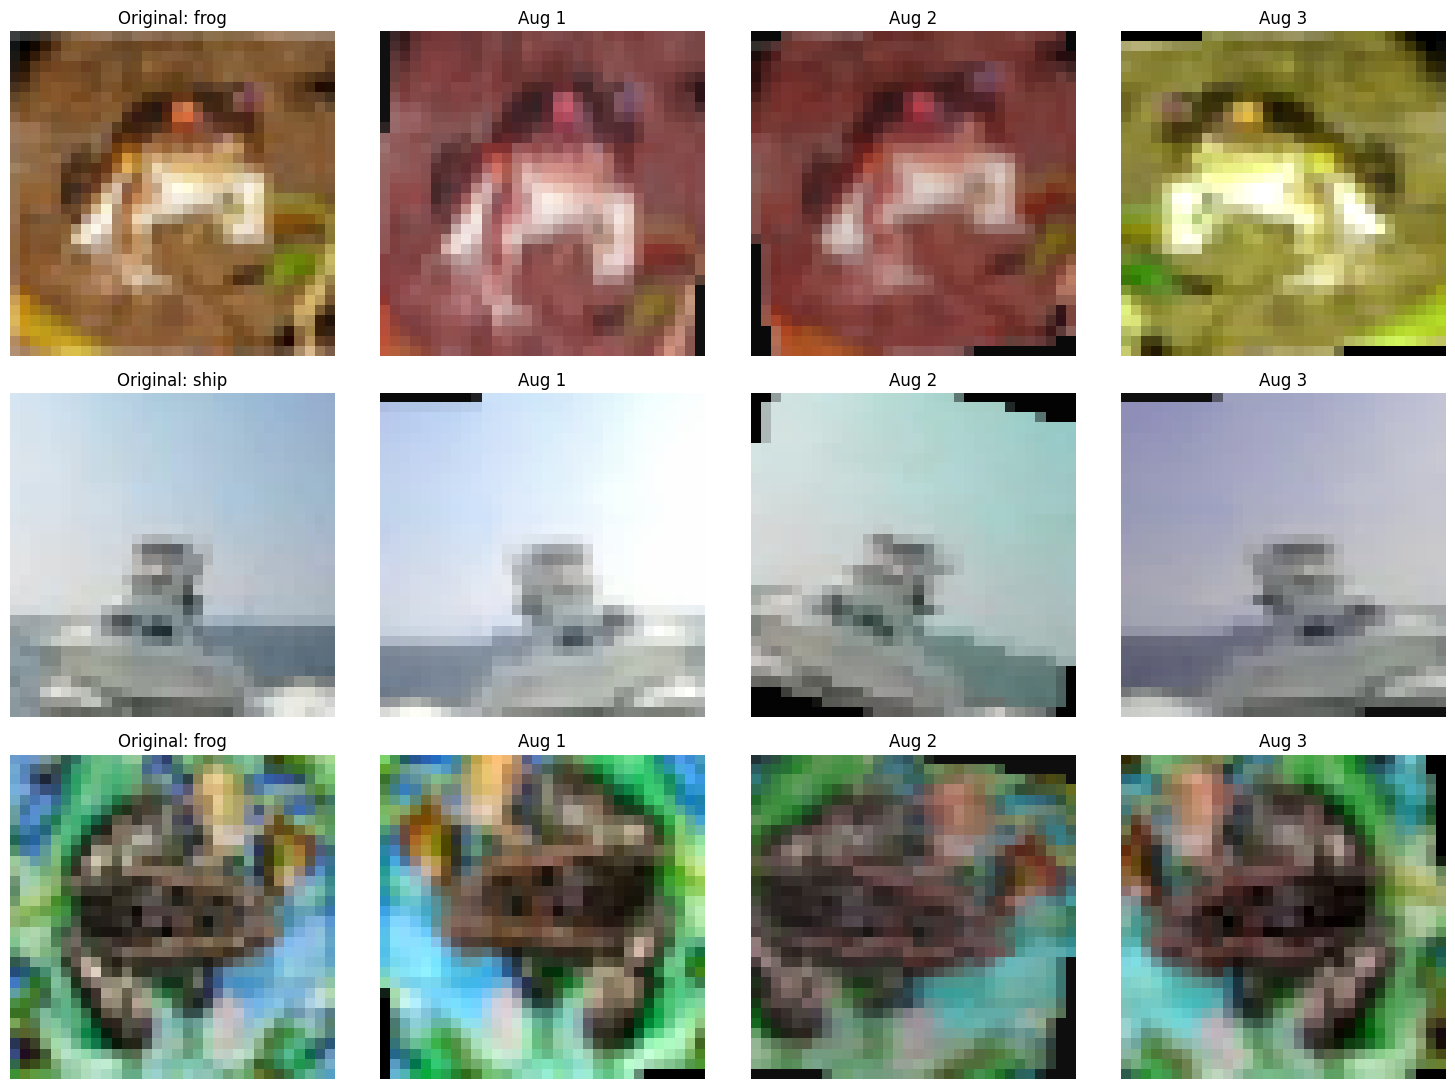

In [20]:
# Get 3 different original images
indices = [0, 100, 200]
original_images = [dataset[i][0] for i in indices]
labels = [class_names[dataset[i][1]] for i in indices]

# Create augmented versions
augmented_versions = [[augmentation_pipeline(img) for _ in range(3)] for img in original_images]

# Display
fig, axes = plt.subplots(3, 4, figsize=(15, 11))

for row in range(3):
    # Original in first column
    img_np = original_images[row].permute(1, 2, 0).numpy()
    axes[row, 0].imshow(np.clip(img_np, 0, 1))
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"Original: {labels[row]}")
    
    # Augmented in other columns
    for col in range(1, 4):
        img_np = augmented_versions[row][col-1].permute(1, 2, 0).numpy()
        axes[row, col].imshow(np.clip(img_np, 0, 1))
        axes[row, col].axis('off')
        axes[row, col].set_title(f"Aug {col}")

plt.tight_layout()
plt.show()

## 9. Augmentation Strategies

Different tasks require different augmentation strategies. Let's explore three common approaches.

### 9.1 Weak Augmentation

Use when:
- You have a large dataset
- Image quality is important
- Small variations are sufficient

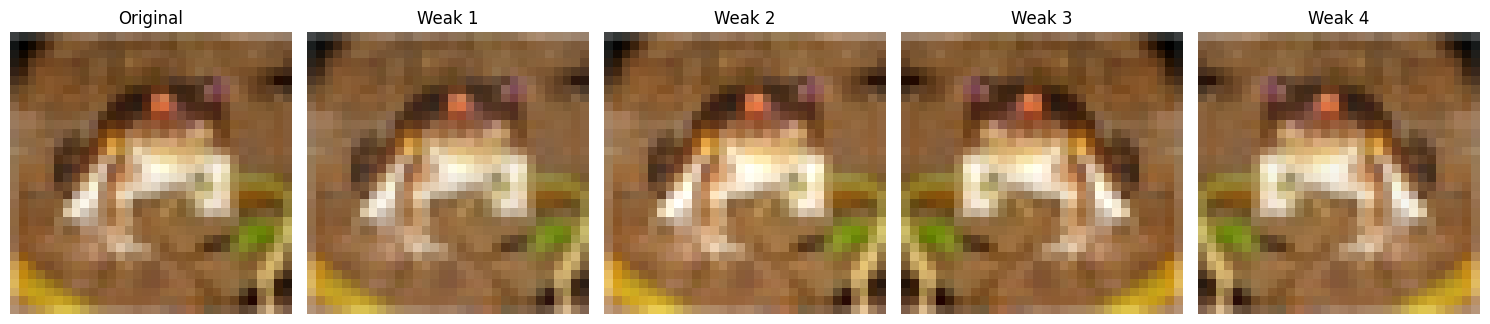

In [21]:
weak_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
])

weak_augmented = [weak_aug(sample_img) for _ in range(4)]
show_images([sample_img] + weak_augmented,
            titles=["Original"] + [f"Weak {i+1}" for i in range(4)])

### 9.2 Standard Augmentation

Use when:
- Moderate dataset size
- General object recognition
- Balanced between diversity and quality

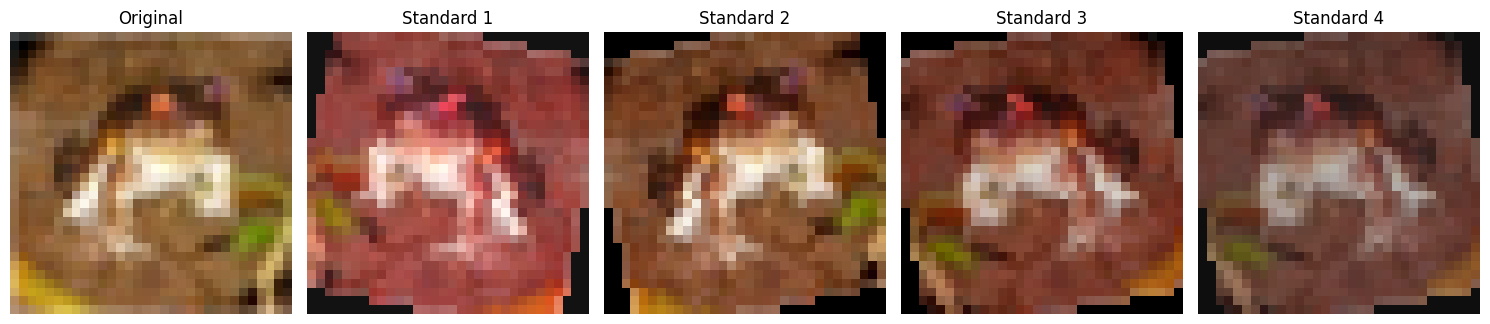

In [22]:
standard_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
])

standard_augmented = [standard_aug(sample_img) for _ in range(4)]
show_images([sample_img] + standard_augmented,
            titles=["Original"] + [f"Standard {i+1}" for i in range(4)])

### 9.3 Strong Augmentation

Use when:
- Small dataset (need maximum diversity)
- Model is overfitting
- Task requires extreme robustness

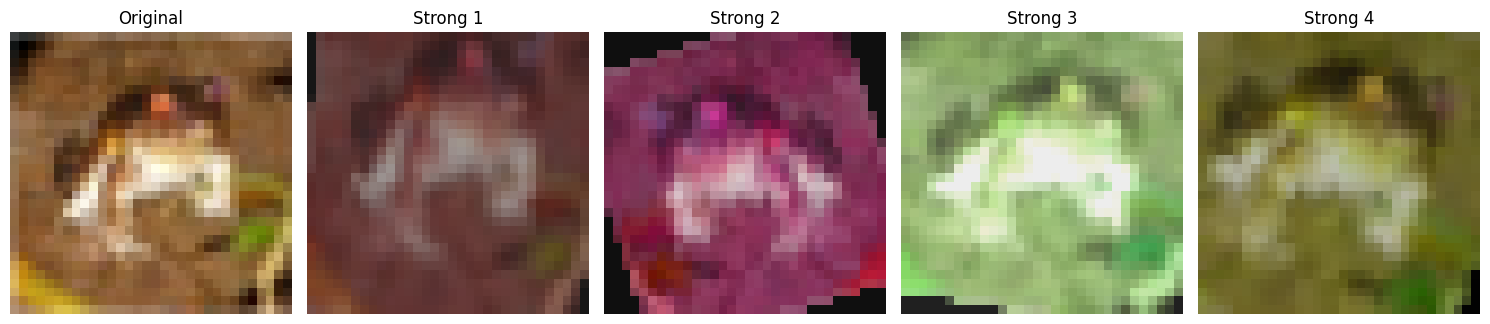

In [23]:
strong_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.RandomResizedCrop(size=32, scale=(0.6, 1.0)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
])

strong_augmented = [strong_aug(sample_img) for _ in range(4)]
show_images([sample_img] + strong_augmented,
            titles=["Original"] + [f"Strong {i+1}" for i in range(4)])

Notice the progression: weak augmentation makes subtle changes, while strong augmentation creates dramatically different images.

## 10. Augmentation in Practice

Let's see how augmentation affects actual training by comparing dataset distributions.

Create datasets with and without augmentation.

In [24]:
# No augmentation (just convert to tensor)
transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
])

# With augmentation
transform_with_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
])

dataset_no_aug = CIFAR10(root='./data', train=True, download=False, transform=transform_no_aug)
dataset_with_aug = CIFAR10(root='./data', train=True, download=False, transform=transform_with_aug)

Visualize how augmentation increases diversity by showing multiple draws of the same image.

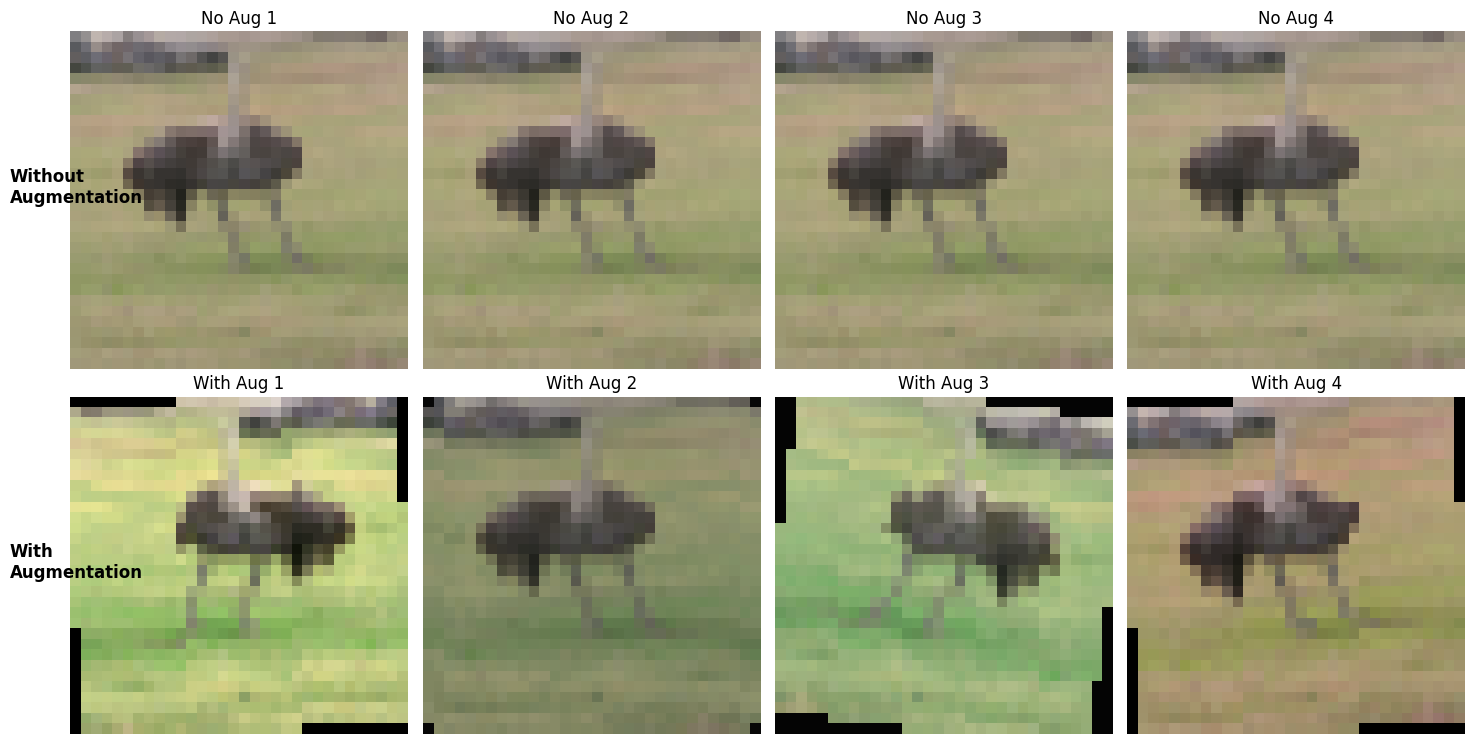

In [25]:
# Sample the same image multiple times
sample_idx = 42

# Without augmentation - always identical
no_aug_samples = [dataset_no_aug[sample_idx][0] for _ in range(4)]

# With augmentation - different each time!
aug_samples = [dataset_with_aug[sample_idx][0] for _ in range(4)]

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))

# Top row: no augmentation
for i in range(4):
    img_np = no_aug_samples[i].permute(1, 2, 0).numpy()
    axes[0, i].imshow(np.clip(img_np, 0, 1))
    axes[0, i].axis('off')
    axes[0, i].set_title(f"No Aug {i+1}")

# Bottom row: with augmentation
for i in range(4):
    img_np = aug_samples[i].permute(1, 2, 0).numpy()
    axes[1, i].imshow(np.clip(img_np, 0, 1))
    axes[1, i].axis('off')
    axes[1, i].set_title(f"With Aug {i+1}")

fig.text(0.02, 0.75, 'Without\nAugmentation', fontsize=12, weight='bold', va='center')
fig.text(0.02, 0.25, 'With\nAugmentation', fontsize=12, weight='bold', va='center')

plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

**Key insight**: Without augmentation, every epoch sees identical images. With augmentation, the model sees different variations every epoch—effectively multiplying your dataset size!

## 11. Best Practices

Here are key principles for effective data augmentation.

### 11.1 Preserve Semantic Meaning

**Rule**: Augmentations must not change the label.

- ✅ Good: Rotating a cat 15° (still a cat)
- ✅ Good: Brightening a car (still a car)
- ❌ Bad: Flipping digits vertically (6 becomes 9!)
- ❌ Bad: Extreme hue shifts that change color-dependent classes

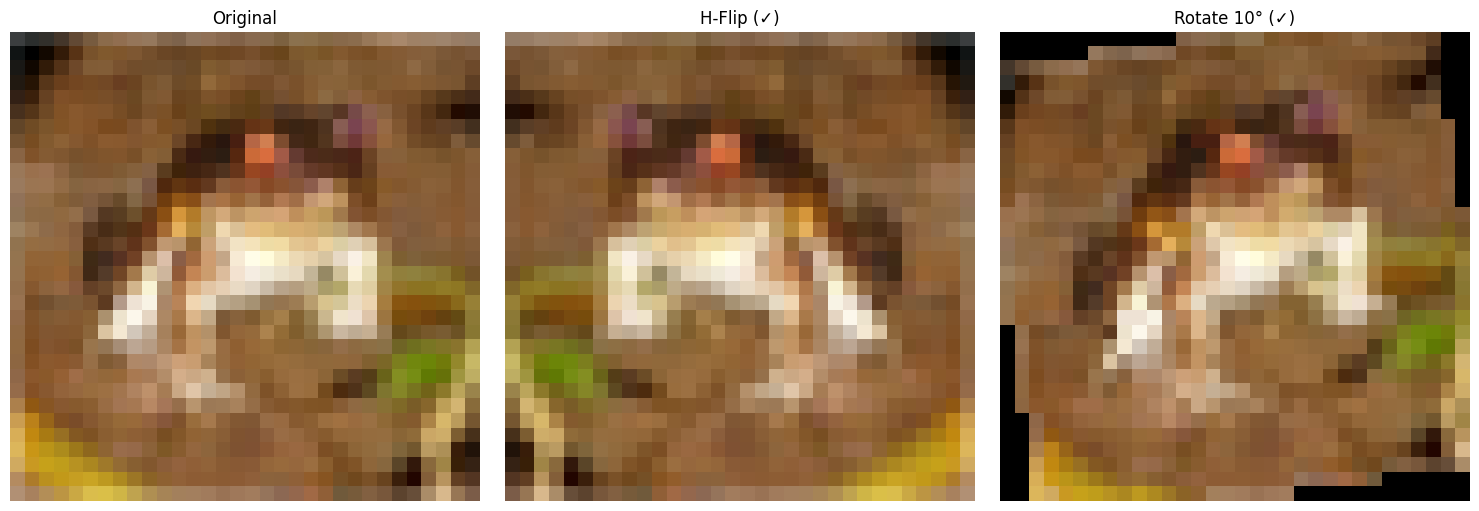

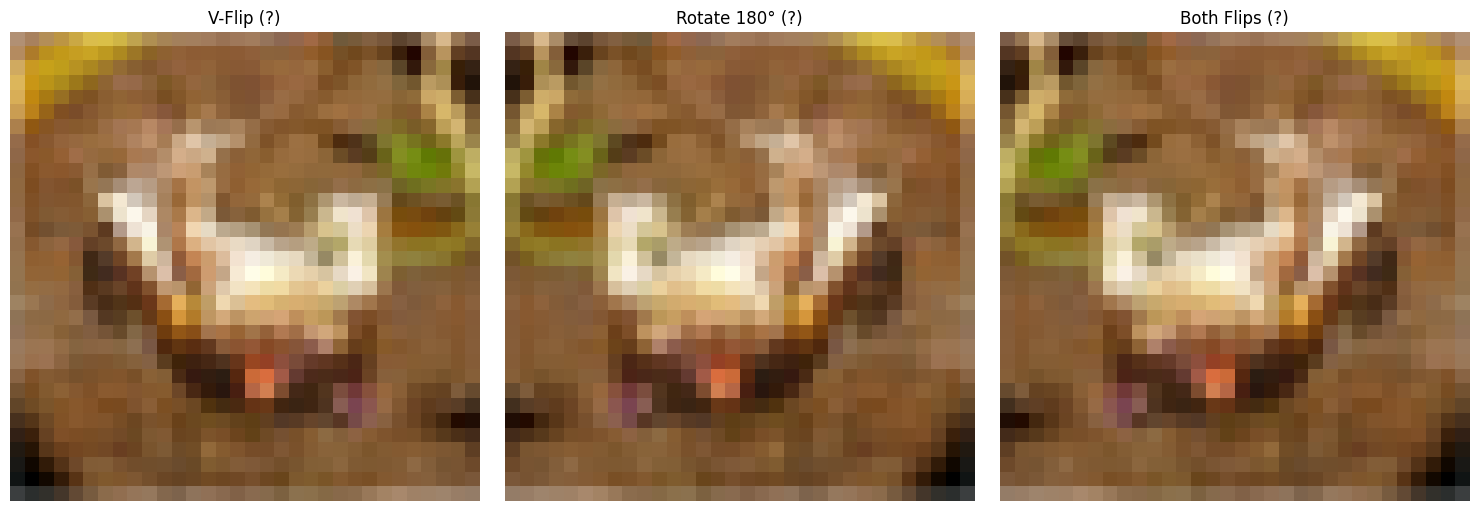

In [26]:
# Example: Why vertical flip is dangerous for some tasks
# Let's use an airplane - vertical flip creates an unrealistic pose
natural_poses = [sample_img, TF.hflip(sample_img), TF.rotate(sample_img, 10)]
unnatural_poses = [TF.vflip(sample_img), TF.rotate(sample_img, 180), TF.vflip(TF.hflip(sample_img))]

show_images(natural_poses, titles=["Original", "H-Flip (✓)", "Rotate 10° (✓)"])
show_images(unnatural_poses, titles=["V-Flip (?)", "Rotate 180° (?)", "Both Flips (?)"])

### 11.2 Train vs. Test Augmentation

**Critical rule**: Only augment training data, never test data!

- **Training**: Apply random augmentations
- **Validation/Test**: Only apply necessary preprocessing (resize, normalize)

Why? We want to evaluate model performance on clean, unmodified images.

In [27]:
# Correct approach
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),  # No augmentation!
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Train transform (with augmentation):")
print(train_transform)
print("\nTest transform (no augmentation):")
print(test_transform)

Train transform (with augmentation):
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Test transform (no augmentation):
Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 11.3 Start Simple, Then Increase

**Strategy**: Begin with minimal augmentation, then gradually increase if the model is overfitting.

1. **Baseline**: Train without augmentation
2. **Weak aug**: Add simple flips and small color jitter
3. **Medium aug**: Add rotation and cropping
4. **Strong aug**: Increase ranges if still overfitting

### 11.4 Monitor Training Dynamics

**Too little augmentation**: Model overfits (train loss << val loss)
**Too much augmentation**: Model underfits (train loss high, slow convergence)
**Just right**: Train and val losses converge smoothly

## 12. Summary and Key Takeaways

**Core Augmentation Techniques**:
- **Rotation**: Makes models orientation-invariant (use ±15° for most tasks)
- **Horizontal Flip**: Doubles effective dataset size (safe for most objects)
- **Random Crop**: Teaches partial object recognition and translation invariance
- **Color Jitter**: Robustness to lighting and camera variations

**Key Principles**:
1. **Preserve labels**: Augmentations must not change semantic meaning
2. **Train only**: Never augment validation/test data
3. **Task-specific**: Choose augmentations that match real-world variations
4. **Start simple**: Increase augmentation gradually if overfitting occurs
5. **Combine intelligently**: Multiple weak augmentations > one strong augmentation

**When to Use Each Strategy**:
- **Small dataset** → Strong augmentation
- **Large dataset** → Weak augmentation
- **Overfitting** → Increase augmentation
- **Underfitting** → Decrease augmentation or remove entirely

**The Bottom Line**: Data augmentation is one of the most effective regularization techniques in deep learning. It's simple, widely applicable, and often provides 2-5% accuracy improvements with minimal effort.

## 13. Further Exploration

Advanced augmentation techniques to explore:
- **Mixup**: Blend two images and their labels
- **CutMix**: Cut and paste patches between images
- **AutoAugment**: Learn optimal augmentation policies
- **RandAugment**: Simplified random augmentation
- **Domain-specific**: Elastic deformations (medical), blur (optical), noise (astronomy)

Try experimenting with different augmentation strategies on your own datasets!